In [52]:
import torch
from src.model import MultitaskAutoencoder
from src.io.offline import load_raw_data
from src.signal.passivesonar import lofar
from src.signal.utils import resample
from pathlib import Path
import numpy as np
import os
import matplotlib.pyplot as plt
import json
import argparse

from src.data_handling import CustomDataloader, LoroCV
from src.visualization import plot_lofargram, plot_tsne_embeddings, palette
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader
from src.training import MultitaskTrainer, calculate_class_weights
import matplotlib

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
def load_embeddings_and_targets(results_path):
    """
    Load embeddings and target arrays from .npy files.

    Parameters:
        results_path (Path): Path object to the directory where files are saved.

    Returns:
        embeddings (list of arrays): List of embedding arrays loaded from files.
        all_targets (list of arrays): List of target arrays loaded from files.
    """
    embeddings = []
    all_targets = []
    
    # Get sorted lists of all embedding and target files
    embedding_files = sorted(results_path.glob("embeddings_fold_*.npy"))
    target_files = sorted(results_path.glob("all_targets_fold_*.npy"))

    for emb_file, target_file in zip(embedding_files, target_files):
        embedding = np.load(emb_file)
        target = np.load(target_file)
        embeddings.append(embedding)
        all_targets.append(target)

    return embeddings, all_targets

## Multitask Autoencoder Analysis

In [54]:
# config_filename = "multitask_autoencoder"
# # Load configuration from the specified config file
# debug = True
# model_name = "MultitaskAutoencoder"

# lr = 0.001
# output = 4
# for window in [16, 32]:
#     for alpha in [0.0, 0.2, 0.5, 0.8]:
#         for ltd in [32, 64, 128]:
#             model_name = f"alpha_{alpha}_latent_{ltd}_output_{output}_window_{window}_lr_{lr}"

# if debug:
#     results_path = Path(f"./results/debug/{model_name}")
# else:
#     results_path = Path(f"./results/production/{model_name}")

# embeddings, all_targets = load_embeddings_and_targets(results_path / "data")

In [55]:
# fig, ax = plt.subplots(figsize=(8, 8/ 1.618))
# plot_tsne_embeddings(ax, embeddings[0], all_targets[0], palette=palette)
# plt.show()

## Unet analysis

In [56]:
config_filename = "MultitaskUNet"
# Load configuration from the specified config file
debug = False
model_id = "MultitaskUNet"

lr = 0.001
output = 4
emb_dict = dict()
trgt_dict = dict()
for window in [16, 32]:
    for alpha in [0.0, 0.2, 0.5, 0.8]:
        for ltd in [32, 64, 128]:
            if alpha == 0.0:
                alpha = 0
            model_name = f"alpha_{alpha}_latent_{ltd}_output_{output}_window_{window}_lr_{lr}"

            if debug:
                results_path = Path(f"./results/debug/{model_id}/{model_name}")
            else:
                results_path = Path(f"./results/production/{model_id}/{model_name}")

            embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
            emb_dict[model_name] = embeddings[0]
            trgt_dict[model_name] = all_targets[0]

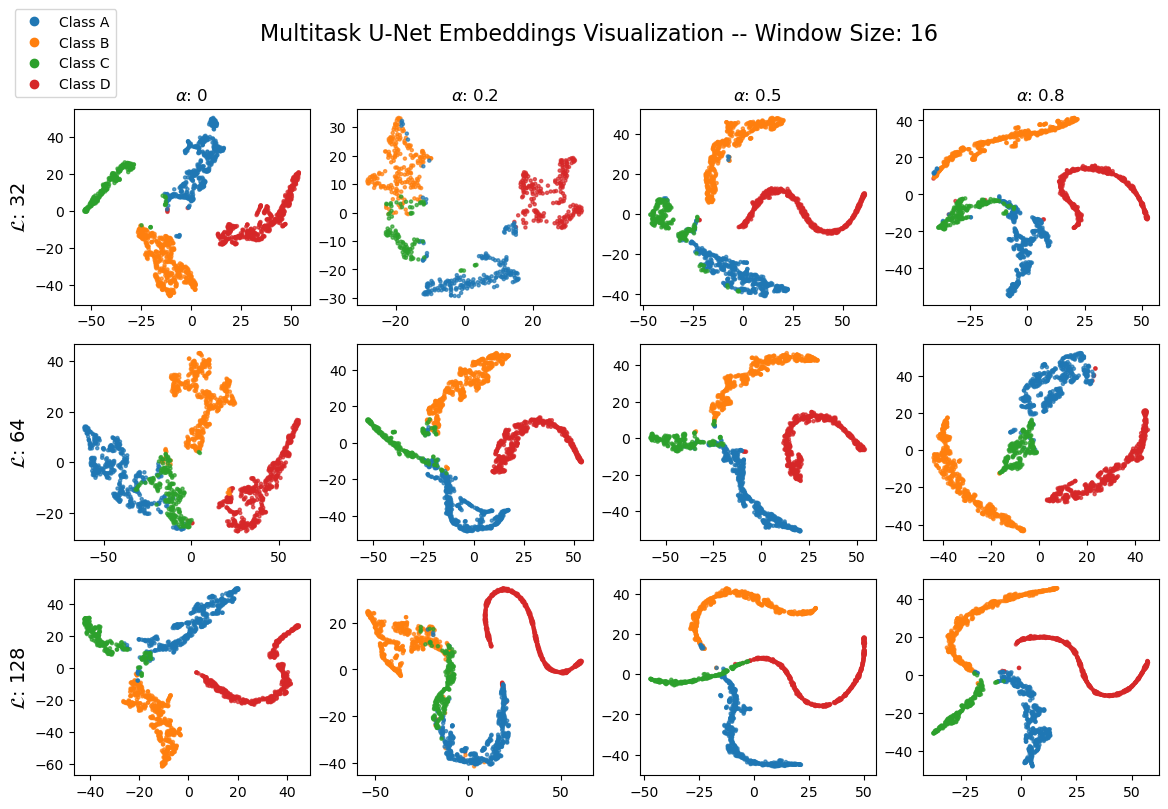

In [57]:
window = 16
fig, axes = plt.subplots(3, 4, figsize=(14, 14/ 1.618))
for i, alpha in enumerate([0.0, 0.2, 0.5, 0.8]):
    for j, ltd in enumerate([32, 64, 128]):
        if alpha == 0.0:
            alpha = 0
       
        if j == 0 and i == 1:
            model_name = f"alpha_{alpha}_latent_{ltd}_output_{output}_window_32_lr_{0.0001}"
            results_path = Path(f"./results/production/{model_id}/{model_name}")
            embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
            embeddings = embeddings[0]
            all_targets = all_targets[0]    
        elif j == 0 and i == 1:
            model_name = f"alpha_{alpha}_latent_{ltd}_output_{output}_window_{window}_lr_{0.0001}"
            results_path = Path(f"./results/production/{model_id}/{model_name}")
            embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
            embeddings = embeddings[0]
            all_targets = all_targets[0]    
        elif j == 1 and i == 0:
            model_name = f"alpha_{alpha}_latent_{ltd}_output_{output}_window_{window}_lr_{0.0001}"
            results_path = Path(f"./results/production/{model_id}/{model_name}")
            embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
            embeddings = embeddings[0]
            all_targets = all_targets[0]    
        elif j == 2 and i == 1:
            model_name = f"alpha_{alpha}_latent_{ltd}_output_{output}_window_{window}_lr_{0.0001}"
            results_path = Path(f"./results/production/{model_id}/{model_name}")
            embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
            embeddings = embeddings[0]
            all_targets = all_targets[0]    
        else:
            model_name = f"alpha_{alpha}_latent_{ltd}_output_{output}_window_{window}_lr_{lr}"
        
            embeddings =  emb_dict[model_name]
            all_targets = trgt_dict[model_name]

        if j == 0:
            title = f"$\\alpha$: {alpha}"
        else:
            title = ""
        # title = f"{j}, {i}"
        if i == 0:
            ylabel = f"$\\mathcal{{L}}$: {ltd}"
            axes[j, i].set_ylabel(ylabel, fontsize=14)
        handles = plot_tsne_embeddings(axes[j, i], embeddings, all_targets, palette=palette, title=title)
        if i == 0 and j == 0:
            axes[j, i].legend(handles=handles, bbox_to_anchor=(-0.25, 1.06), loc='lower left', borderaxespad=0)
fig.suptitle(f"Multitask U-Net Embeddings Visualization -- Window Size: {window}", fontsize=16)
plt.show()

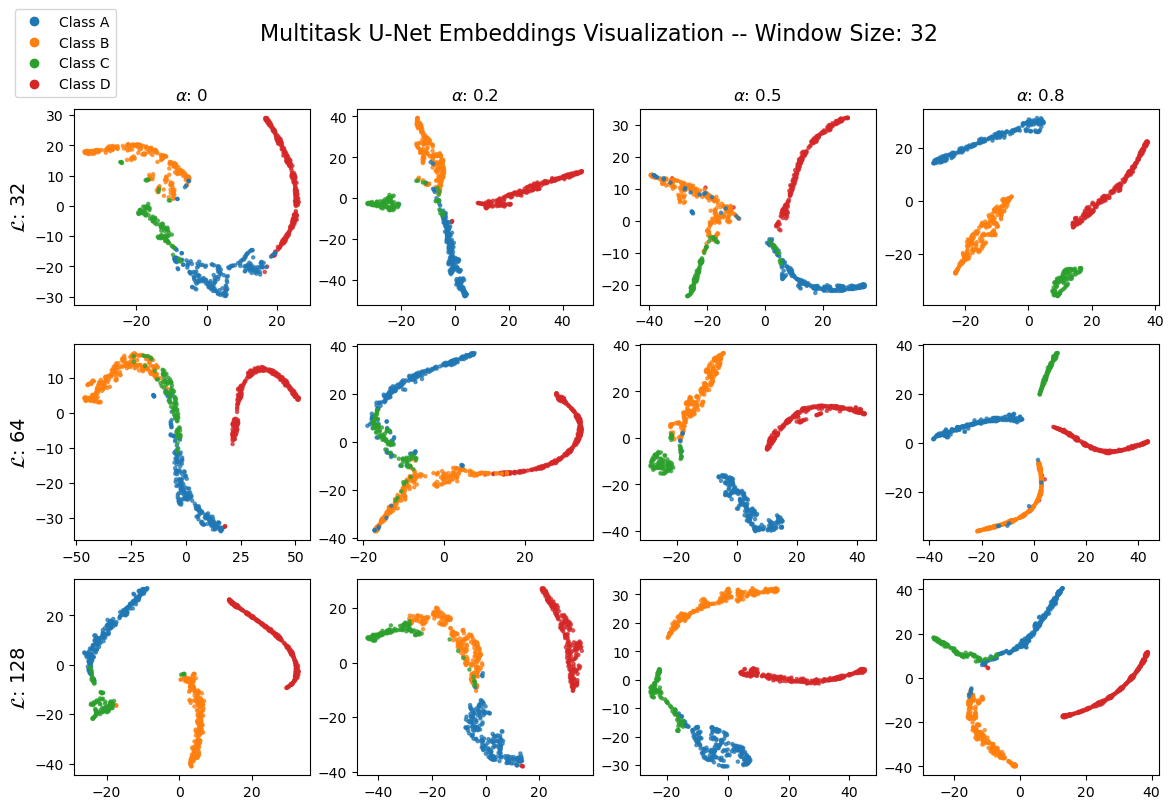

In [58]:
window = 32
fig, axes = plt.subplots(3, 4, figsize=(14, 14/ 1.618))
for i, alpha in enumerate([0.0, 0.2, 0.5, 0.8]):
    for j, ltd in enumerate([32, 64, 128]):
        if alpha == 0.0:
            alpha = 0
       
        if j == 0 and i == 1:
            model_name = f"alpha_{alpha}_latent_{ltd}_output_{output}_window_32_lr_{0.001}"
            results_path = Path(f"./results/production/{model_id}/{model_name}")
            embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
            embeddings = embeddings[0]
            all_targets = all_targets[0]    
        elif j == 0 and i == 1:
            model_name = f"alpha_{alpha}_latent_{ltd}_output_{output}_window_{window}_lr_{0.0001}"
            results_path = Path(f"./results/production/{model_id}/{model_name}")
            embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
            embeddings = embeddings[0]
            all_targets = all_targets[0]    
        elif j == 1 and i == 0:
            model_name = f"alpha_{alpha}_latent_{ltd}_output_{output}_window_{window}_lr_{0.0001}"
            results_path = Path(f"./results/production/{model_id}/{model_name}")
            embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
            embeddings = embeddings[0]
            all_targets = all_targets[0]    
        elif j == 2 and i == 1:
            model_name = f"alpha_{alpha}_latent_{ltd}_output_{output}_window_{window}_lr_{0.0001}"
            results_path = Path(f"./results/production/{model_id}/{model_name}")
            embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
            embeddings = embeddings[0]
            all_targets = all_targets[0]    
        else:
            model_name = f"alpha_{alpha}_latent_{ltd}_output_{output}_window_{window}_lr_{lr}"
        
            embeddings =  emb_dict[model_name]
            all_targets = trgt_dict[model_name]

        if j == 0:
            title = f"$\\alpha$: {alpha}"
        else:
            title = ""
        # title = f"{j}, {i}"
        if i == 0:
            ylabel = f"$\\mathcal{{L}}$: {ltd}"
            axes[j, i].set_ylabel(ylabel, fontsize=14)
        handles = plot_tsne_embeddings(axes[j, i], embeddings, all_targets, palette=palette, title=title)
        if i == 0 and j == 0:
            axes[j, i].legend(handles=handles, bbox_to_anchor=(-0.25, 1.06), loc='lower left', borderaxespad=0)
fig.suptitle(f"Multitask U-Net Embeddings Visualization -- Window Size: {window}", fontsize=16)
plt.show()

## conv mt ae

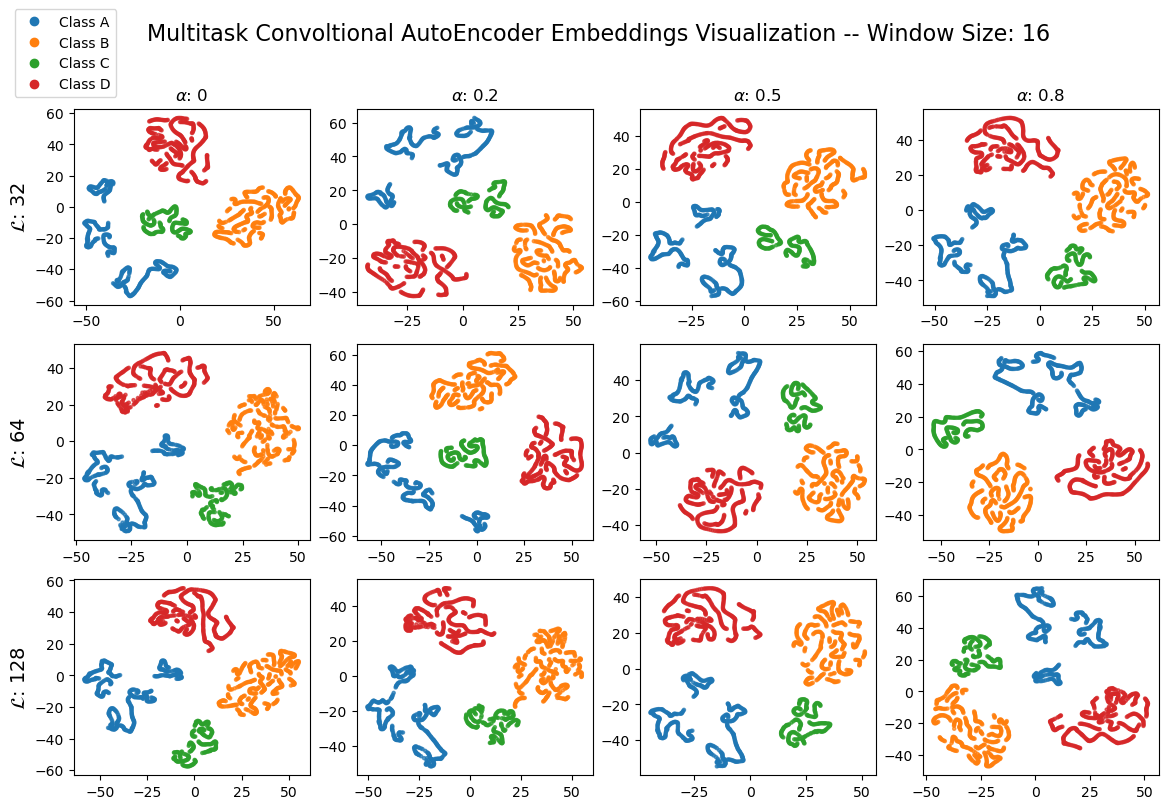

In [59]:
config_filename = "ConvAutoencoderMultitask"
# Load configuration from the specified config file
debug = False
model_id = "ConvAutoencoderMultitask"

lr = 0.001
output = 4
emb_dict = dict()
trgt_dict = dict()
for window in [16, 32]:
    for alpha in [0.0, 0.2, 0.5, 0.8]:
        for ltd in [32, 64, 128]:
            if alpha == 0.0:
                alpha = 0
            model_name = f"alpha_{alpha}_latent_{ltd}_output_{output}_window_{window}_lr_{lr}"

            if debug:
                results_path = Path(f"./results/debug/{model_id}/{model_name}")
            else:
                results_path = Path(f"./results/production/{model_id}/{model_name}")

            embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
            emb_dict[model_name] = embeddings[0]
            trgt_dict[model_name] = all_targets[0]

window = 16
fig, axes = plt.subplots(3, 4, figsize=(14, 14/ 1.618))
for i, alpha in enumerate([0.0, 0.2, 0.5, 0.8]):
    for j, ltd in enumerate([32, 64, 128]):
        if alpha == 0.0:
            alpha = 0
       
        # if j == 0 and i == 1:
        #     model_name = f"alpha_{alpha}_latent_{ltd}_output_{output}_window_32_lr_{0.0001}"
        #     results_path = Path(f"./results/production/{model_id}/{model_name}")
        #     embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
        #     embeddings = embeddings[0]
        #     all_targets = all_targets[0]    
        # elif j == 0 and i == 1:
        #     model_name = f"alpha_{alpha}_latent_{ltd}_output_{output}_window_{window}_lr_{0.0001}"
        #     results_path = Path(f"./results/production/{model_id}/{model_name}")
        #     embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
        #     embeddings = embeddings[0]
        #     all_targets = all_targets[0]    
        # elif j == 1 and i == 0:
        #     model_name = f"alpha_{alpha}_latent_{ltd}_output_{output}_window_{window}_lr_{0.0001}"
        #     results_path = Path(f"./results/production/{model_id}/{model_name}")
        #     embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
        #     embeddings = embeddings[0]
        #     all_targets = all_targets[0]    
        # elif j == 2 and i == 1:
        #     model_name = f"alpha_{alpha}_latent_{ltd}_output_{output}_window_{window}_lr_{0.0001}"
        #     results_path = Path(f"./results/production/{model_id}/{model_name}")
        #     embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
        #     embeddings = embeddings[0]
        #     all_targets = all_targets[0]    
        # else:
        model_name = f"alpha_{alpha}_latent_{ltd}_output_{output}_window_{window}_lr_{lr}"
    
        embeddings =  emb_dict[model_name]
        all_targets = trgt_dict[model_name]

        if j == 0:
            title = f"$\\alpha$: {alpha}"
        else:
            title = ""
        # title = f"{j}, {i}"
        if i == 0:
            ylabel = f"$\\mathcal{{L}}$: {ltd}"
            axes[j, i].set_ylabel(ylabel, fontsize=14)
        handles = plot_tsne_embeddings(axes[j, i], embeddings, all_targets, palette=palette, title=title)
        if i == 0 and j == 0:
            axes[j, i].legend(handles=handles, bbox_to_anchor=(-0.25, 1.06), loc='lower left', borderaxespad=0)

fig.suptitle(f"Multitask Convoltional AutoEncoder Embeddings Visualization -- Window Size: {window}", fontsize=16)
plt.show()

## same for ws 32

In [60]:
config_filename = "MultitaskAutoencoder"
# Load configuration from the specified config file
debug = False
model_id = "MultitaskAutoencoder"

lr = 0.001
output = 4
emb_dict = dict()
trgt_dict = dict()
for alpha in [0.0, 0.2, 0.5, 0.8]:
    for ltd in [32, 64, 128]:
        if alpha == 0.0:
            alpha = 0
        model_name = f"alpha_{alpha}_latent_{ltd}_window_None_lr_{lr}"

        if debug:
            results_path = Path(f"./results/debug/{model_id}/{model_name}")
        else:
            results_path = Path(f"./results/production/{model_id}/{model_name}")
        if not results_path.exists():
            continue
        embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
        emb_dict[model_name] = embeddings[0]
        trgt_dict[model_name] = all_targets[0]


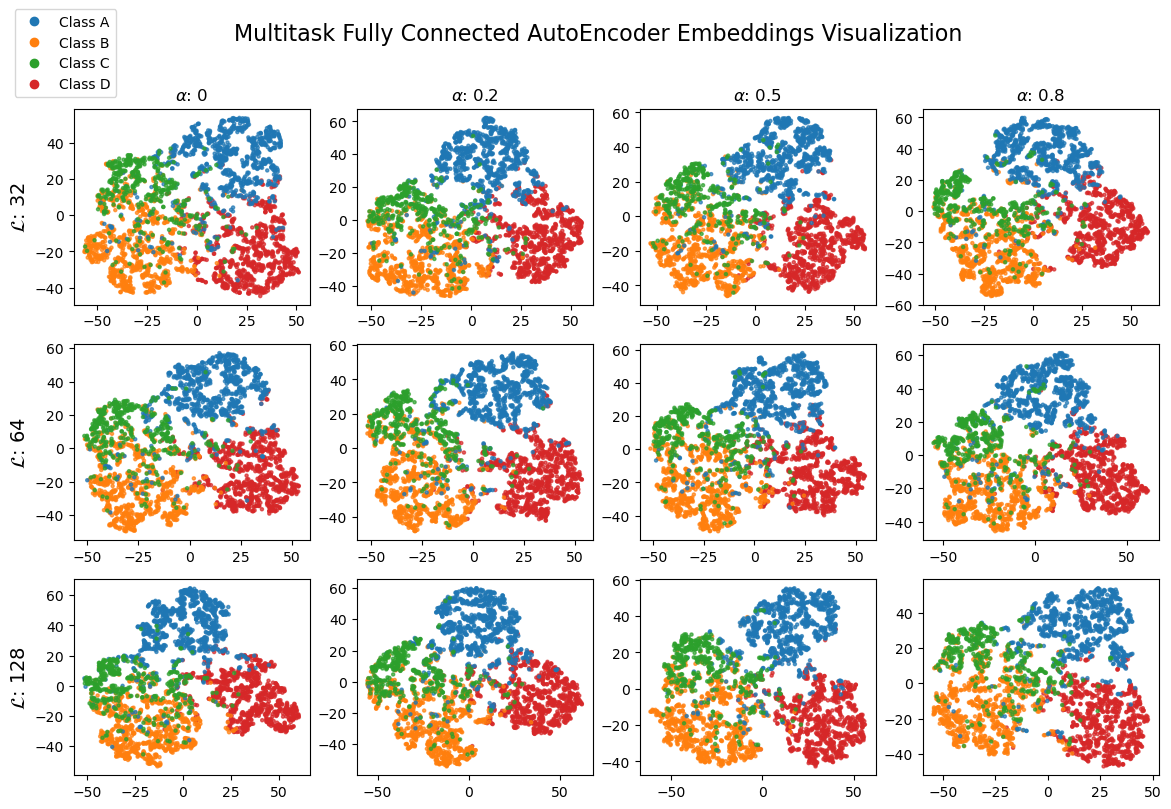

In [61]:

fig, axes = plt.subplots(3, 4, figsize=(14, 14/ 1.618))
for i, alpha in enumerate([0.0, 0.2, 0.5, 0.8]):
    for j, ltd in enumerate([32, 64, 128]):
        if alpha == 0.0:
            alpha = 0
       
        # if j == 0 and i == 1:
        #     model_name = f"alpha_{alpha}_latent_{ltd}_output_{output}_window_32_lr_{0.0001}"
        #     results_path = Path(f"./results/production/{model_id}/{model_name}")
        #     embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
        #     embeddings = embeddings[0]
        #     all_targets = all_targets[0]    
        # elif j == 0 and i == 1:
        #     model_name = f"alpha_{alpha}_latent_{ltd}_output_{output}_window_{window}_lr_{0.0001}"
        #     results_path = Path(f"./results/production/{model_id}/{model_name}")
        #     embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
        #     embeddings = embeddings[0]
        #     all_targets = all_targets[0]    
        # elif j == 1 and i == 0:
        #     model_name = f"alpha_{alpha}_latent_{ltd}_output_{output}_window_{window}_lr_{0.0001}"
        #     results_path = Path(f"./results/production/{model_id}/{model_name}")
        #     embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
        #     embeddings = embeddings[0]
        #     all_targets = all_targets[0]    
        # elif j == 2 and i == 1:
        #     model_name = f"alpha_{alpha}_latent_{ltd}_output_{output}_window_{window}_lr_{0.0001}"
        #     results_path = Path(f"./results/production/{model_id}/{model_name}")
        #     embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
        #     embeddings = embeddings[0]
        #     all_targets = all_targets[0]    
        # else:
        # model_name = f"alpha_{alpha}_latent_{ltd}_window_None_lr_{lr}"
        # if model_name ==  'alpha_0.5_latent_32_window_None_lr_0.001':
        #     model_name =  'alpha_0.5_latent_32_window_None_lr_0.01'
        #     results_path = Path(f"./results/production/{model_id}/{model_name}")
        #     embeddings, all_targets = load_embeddings_and_targets(results_path / "data")
        #     embeddings = embeddings[0]
        # if model_name == 'alpha_0.5_latent_64_window_None_lr_0.001':
        #     continue
        # if model_name == 'alpha_0.5_latent_128_window_None_lr_0.001':
        #     continue
        # else:
        model_name = f"alpha_{alpha}_latent_{ltd}_window_None_lr_{lr}"

        embeddings =  emb_dict[model_name]
        all_targets = trgt_dict[model_name]

        if j == 0:
            title = f"$\\alpha$: {alpha}"
        else:
            title = ""
        # title = f"{j}, {i}"
        if i == 0:
            ylabel = f"$\\mathcal{{L}}$: {ltd}"
            axes[j, i].set_ylabel(ylabel, fontsize=14)
        handles = plot_tsne_embeddings(axes[j, i], embeddings, all_targets, palette=palette, title=title)
        if i == 0 and j == 0:
            axes[j, i].legend(handles=handles, bbox_to_anchor=(-0.25, 1.06), loc='lower left', borderaxespad=0)
fig.suptitle(f"Multitask Fully Connected AutoEncoder Embeddings Visualization", fontsize=16)
plt.show()